SVM · Random Forest · XGBoost

> **Instructions**  
> - Cells marked `# YOUR CODE HERE` are for you to complete.  
> - Try not to modify the pre-filled cells (data loading, preprocessing).  
> - Run cells in order from top to bottom.  
> - Fill the comparison table and answer the 3 discussion questions at the end.


##  Setup

In [1]:
# Run this cell first — installs XGBoost if not already available
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "xgboost", "-q"])


CompletedProcess(args=['/opt/homebrew/opt/python@3.11/bin/python3.11', '-m', 'pip', 'install', 'xgboost', '-q'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, classification_report)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
import time

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print("XGBoost loaded successfully.")
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost not found — GradientBoostingClassifier will be used as fallback.")

print("All libraries loaded.")


XGBoost loaded successfully.
All libraries loaded.


## Data loading & preprocessing
This section loads `predict_income.csv`, handles categorical encoding, and prepares the train/test split.


In [3]:
# ── Load dataset ──────────────────────────────────────────────────────────────

# from google.colab import files
# uploaded = files.upload()          # select predict_income.csv when prompted
# df = pd.read_csv(list(uploaded.keys())[0])
df = pd.read_csv('predict_income.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (48842, 15)

First 5 rows:


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:

print("Column names and dtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df['income'].value_counts())


Column names and dtypes:
age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object

Missing values:
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

Target distribution:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [5]:
# Encode categorical columns
df_enc = df.copy()
label_encoders = {}

categorical_cols = df_enc.select_dtypes(include=['object']).columns.tolist()
# Remove target from encoding list if it appears
if 'income' in categorical_cols:
    categorical_cols.remove('income')

for col in categorical_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    label_encoders[col] = le

# Encode target: '>50K' → 1, '<=50K' → 0
df_enc['income'] = df_enc['income'].str.strip().map({'>50K': 1, '<=50K': 0,
                                                      '>50K.': 1, '<=50K.': 0})

print("Encoding done. Encoded shape:", df_enc.shape)
print("Target unique values:", df_enc['income'].unique())


Encoding done. Encoded shape: (48842, 15)
Target unique values: [0 1]


In [6]:
# ── Train / test split
X = df_enc.drop(columns=['income'])
y = df_enc['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")
print(f"Features   : {X_train.shape[1]}")
print(f"\nClass balance in train:\n{y_train.value_counts()}")


Train size : 39073 samples
Test size  : 9769 samples
Features   : 14

Class balance in train:
income
0    29724
1     9349
Name: count, dtype: int64


---
## Problem Statement 1 — SVM (Iris dataset)

> This problem uses the **Iris dataset** (Setosa vs Versicolor — binary classification).  
> It is independent of the income dataset above.


In [7]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load Iris — keep only Setosa (0) and Versicolor (1)
iris = load_iris()
mask = iris.target != 2
X_iris = iris.data[mask]
y_iris = iris.target[mask]

# Scale features
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_iris_scaled, y_iris, test_size=0.2, random_state=42)

print("Iris binary dataset ready.")
print(f"Train: {X_tr_i.shape[0]}  |  Test: {X_te_i.shape[0]}")


Iris binary dataset ready.
Train: 80  |  Test: 20


### 1a. Train SVM with linear kernel

In [8]:
# YOUR CODE HERE
# Train an SVM with a linear kernel
# Evaluate using accuracy, precision, recall, F1-score
# Try at least two values of C (e.g., C=0.1 and C=10)

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Try two values of C
C_values = [0.1, 10]

print("----- Linear Kernel SVM -----")

for C in C_values:
    svm_linear = SVC(kernel='linear', C=C)
    svm_linear.fit(X_tr_i, y_tr_i)
    
    y_pred = svm_linear.predict(X_te_i)
    
    print(f"\nC = {C}")
    print("Accuracy :", accuracy_score(y_te_i, y_pred))
    print("Precision:", precision_score(y_te_i, y_pred))
    print("Recall   :", recall_score(y_te_i, y_pred))
    print("F1-score :", f1_score(y_te_i, y_pred))

----- Linear Kernel SVM -----

C = 0.1
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

C = 10
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0


### 1b. Train SVM with RBF kernel

In [9]:
# YOUR CODE HERE
# Train an SVM with RBF kernel
# Try at least two combinations of C and gamma (e.g., C=1 gamma=0.1 and C=10 gamma=1)
# Print classification_report for each

from sklearn.svm import SVC
from sklearn.metrics import classification_report
import pandas as pd

results = []

print("----- RBF Kernel Results -----")

# Try combinations
params = [(1, 0.1), (10, 1)]

for C, gamma in params:
    svm_rbf = SVC(kernel='rbf', C=C, gamma=gamma)
    svm_rbf.fit(X_tr_i, y_tr_i)
    
    y_pred = svm_rbf.predict(X_te_i)
    
    print(f"\nC = {C}, gamma = {gamma}")
    print(classification_report(y_te_i, y_pred))
    
    # Store results for summary
    report = classification_report(y_te_i, y_pred, output_dict=True)
    
    results.append({
        "Model": "RBF",
        "C": C,
        "Gamma": gamma,
        "Accuracy": report["accuracy"],
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-score": report["1"]["f1-score"]
    })

----- RBF Kernel Results -----

C = 1, gamma = 0.1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


C = 10, gamma = 1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



### 1c. Compare kernels and comment

In [10]:
# YOUR CODE HERE
# Print a summary table comparing linear vs RBF results
# (you can use a simple dict → pd.DataFrame)

print("\n----- Linear Kernel Results -----")

C_values = [0.1, 10]

for C in C_values:
    svm_linear = SVC(kernel='linear', C=C)
    svm_linear.fit(X_tr_i, y_tr_i)
    
    y_pred = svm_linear.predict(X_te_i)
    
    print(f"\nC = {C}")
    print(classification_report(y_te_i, y_pred))
    
    report = classification_report(y_te_i, y_pred, output_dict=True)
    
    results.append({
        "Model": "Linear",
        "C": C,
        "Gamma": "-",
        "Accuracy": report["accuracy"],
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-score": report["1"]["f1-score"]
    })


----- Linear Kernel Results -----

C = 0.1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


C = 10
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [11]:
df_results = pd.DataFrame(results)

print("\n===== Comparison Table =====")
print(df_results)


===== Comparison Table =====
    Model     C Gamma  Accuracy  Precision  Recall  F1-score
0     RBF   1.0   0.1       1.0        1.0     1.0       1.0
1     RBF  10.0     1       1.0        1.0     1.0       1.0
2  Linear   0.1     -       1.0        1.0     1.0       1.0
3  Linear  10.0     -       1.0        1.0     1.0       1.0


---
## Problem Statement 2 — Random Forest
> Use `X_train, X_test, y_train, y_test` from the income dataset (already prepared above).


### 2a. Train Random Forest and evaluate

Accuracy: 0.8608864776333299


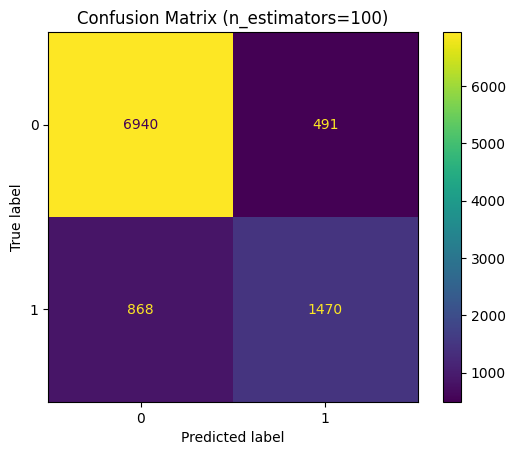

In [12]:
# YOUR CODE HERE
# Train a RandomForestClassifier (use random_state=42)
# Print accuracy and plot the confusion matrix using ConfusionMatrixDisplay

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Confusion Matrix (n_estimators=100)")
plt.show()

### 2b. Feature importance plot

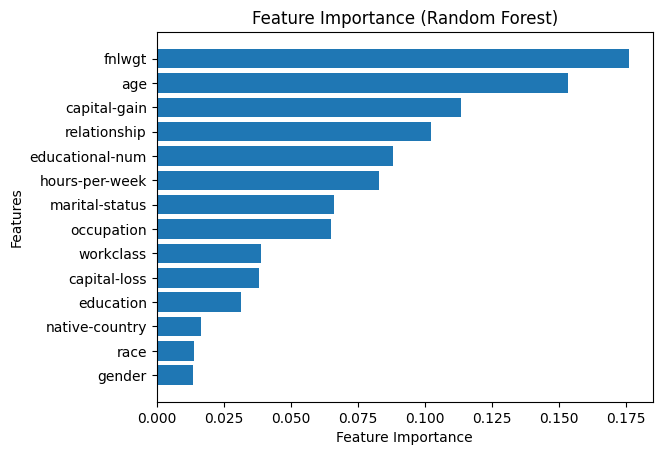

In [13]:
#  YOUR CODE HERE
# Plot a horizontal bar chart of feature importances
# Sort by importance (highest at top)
# Label axes clearly

import numpy as np

# Get feature importance
importances = rf.feature_importances_
feature_names = X.columns

# Sort indices
indices = np.argsort(importances)

# Plot horizontal bar chart
plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), feature_names[indices])

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance (Random Forest)")

plt.show()

### 2c. Effect of n_estimators

In [14]:
#  YOUR CODE HERE
# Train two Random Forest models:
#   - n_estimators = 50
#   - n_estimators = 200
# Record accuracy and training time for each
# Print a comparison

import time

results = []

for n in [50, 200]:
    start = time.time()
    
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    
    end = time.time()
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    train_time = end - start
    
    results.append((n, acc, train_time))
    
    print(f"\nn_estimators = {n}")
    print("Accuracy:", acc)
    print("Training Time:", train_time, "seconds")

# Summary
print("\n===== Comparison Summary =====")
for r in results:
    print(f"Trees: {r[0]} | Accuracy: {r[1]:.4f} | Time: {r[2]:.4f} sec")




n_estimators = 50
Accuracy: 0.8609888422561163
Training Time: 0.9270648956298828 seconds

n_estimators = 200
Accuracy: 0.8622172177295526
Training Time: 3.7718851566314697 seconds

===== Comparison Summary =====
Trees: 50 | Accuracy: 0.8610 | Time: 0.9271 sec
Trees: 200 | Accuracy: 0.8622 | Time: 3.7719 sec


---
## Problem Statement 3 — XGBoost
> Use the same income dataset split. Compare directly with Random Forest.


In [15]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Try importing XGBoost
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print("Using XGBoost ✅")
except:
    from sklearn.ensemble import GradientBoostingClassifier
    XGB_AVAILABLE = False
    print("Using GradientBoosting (fallback) ✅")


Using XGBoost ✅


### 3a. Train XGBoost and evaluate

In [16]:
# YOUR CODE HERE
# If XGB_AVAILABLE is True  → use XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
# If XGB_AVAILABLE is False → use GradientBoostingClassifier(random_state=42)
# Evaluate using accuracy, precision, recall, F1-score
# Record training time using time.time()

start = time.time()

if XGB_AVAILABLE:
    model_xgb = XGBClassifier(use_label_encoder=False,
                              eval_metric='logloss',
                              random_state=42)
else:
    model_xgb = GradientBoostingClassifier(random_state=42)

model_xgb.fit(X_train, y_train)

end = time.time()
train_time_xgb = end - start
# ================================
# Predictions
# ================================
y_pred_xgb = model_xgb.predict(X_test)


# ================================
# Evaluation Metrics
# ================================
acc = accuracy_score(y_test, y_pred_xgb)
prec = precision_score(y_test, y_pred_xgb)
rec = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)

print("\n=== XGBoost / GradientBoosting Results ===")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)
print("Training Time:", train_time_xgb, "seconds")


=== XGBoost / GradientBoosting Results ===
Accuracy : 0.8726584092537619
Precision: 0.7768218623481782
Recall   : 0.6565440547476475
F1-score : 0.7116365322206769
Training Time: 0.15250897407531738 seconds


### 3b. Overfitting check — train vs test score

In [17]:
# YOUR CODE HERE
# Print both train accuracy and test accuracy for:
#   - Your Random Forest model (from PS2a)
#   - Your XGBoost model (from PS3a)
# A large gap between train and test = overfitting

# ================================
# Random Forest Train vs Test
# ================================
rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf.predict(X_test))

# ================================
# XGBoost Train vs Test
# ================================
xgb_train_acc = accuracy_score(y_train, model_xgb.predict(X_train))
xgb_test_acc = accuracy_score(y_test, y_pred_xgb)

print("\n===== Overfitting Comparison =====")

print("\nRandom Forest:")
print("Train Accuracy:", rf_train_acc)
print("Test Accuracy :", rf_test_acc)

print("\nXGBoost / GradientBoosting:")
print("Train Accuracy:", xgb_train_acc)
print("Test Accuracy :", xgb_test_acc)


===== Overfitting Comparison =====

Random Forest:
Train Accuracy: 0.9999232206382924
Test Accuracy : 0.8608864776333299

XGBoost / GradientBoosting:
Train Accuracy: 0.899777339851048
Test Accuracy : 0.8726584092537619


---
## GridSearchCV — hyperparameter tuning
> Apply GridSearchCV to **one** model of your choice: SVM, Random Forest, or XGBoost.  
> Keep the param grid small (2–3 values per parameter) to avoid long runtimes.


In [18]:
# YOUR CODE HERE
# Example param grid for Random Forest (modify as needed):
# param_grid = {
#     'n_estimators': [50, 100],
#     'max_depth': [None, 10],
#     'min_samples_split': [2, 5]
# }
# Use cv=5, scoring='accuracy'
# Print best_params_ and best_score_

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# =========================================
# 1. Define Parameter Grid (Small & Efficient)
# =========================================
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

# =========================================
# 2. Initialize Model
# =========================================
rf = RandomForestClassifier(random_state=42)

# =========================================
# 3. GridSearchCV
# =========================================
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1   # use all cores (faster)
)

# =========================================
# 4. Fit Model
# =========================================
grid_search.fit(X_train, y_train)

# =========================================
# 5. Best Parameters & Score
# =========================================
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Accuracy: 0.8594935022379733


In [19]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Test Accuracy (Best Model):", accuracy_score(y_test, y_pred))

Test Accuracy (Best Model): 0.8619101238611936


---
## ROC Curve — best performing classifier
> Plot the ROC curve for the model that achieved the highest test accuracy.


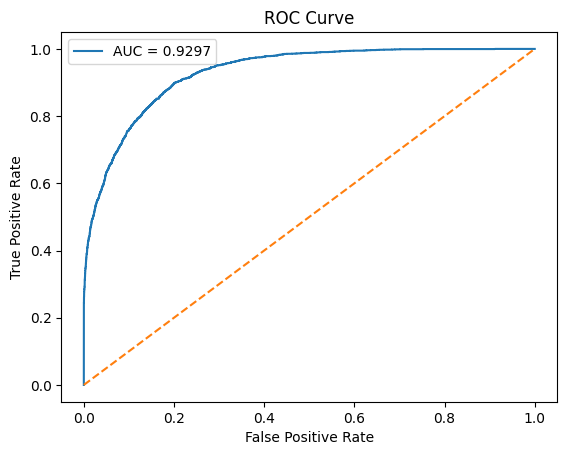

In [20]:
# YOUR CODE HERE
# Use predict_proba() or decision_function() to get scores
# Compute fpr, tpr, thresholds using roc_curve()
# Compute AUC using auc()
# Plot the curve with AUC value in the legend
# Add a dashed diagonal line (random classifier baseline)

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# =========================================
# 1. Get prediction scores
# =========================================
# Use predict_proba if available
if hasattr(model_xgb, "predict_proba"):
    y_scores = model_xgb.predict_proba(X_test)[:, 1]
else:
    y_scores = model_xgb.decision_function(X_test)


# =========================================
# 2. Compute ROC Curve
# =========================================
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# =========================================
# 3. Compute AUC
# =========================================
roc_auc = auc(fpr, tpr)


# =========================================
# 4. Plot ROC Curve
# =========================================
plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

---
## Comparison table
Fill in your actual results below.


In [21]:
#  Fill in your results and run this cell to display the table
# Compare Accuracy, Precision, Recall & F1-score for Model SVM (Linear), SVM (RBF), Random Forest, XGBoost

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

# ================================
# 1. SVM (Linear)
# ================================
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_tr_i, y_tr_i)

y_pred = svm_linear.predict(X_te_i)

results.append({
    "Model": "SVM (Linear)",
    "Accuracy": accuracy_score(y_te_i, y_pred),
    "Precision": precision_score(y_te_i, y_pred),
    "Recall": recall_score(y_te_i, y_pred),
    "F1-score": f1_score(y_te_i, y_pred)
})


# ================================
# 2. SVM (RBF)
# ================================
svm_rbf = SVC(kernel='rbf', C=1, gamma=0.1)
svm_rbf.fit(X_tr_i, y_tr_i)

y_pred = svm_rbf.predict(X_te_i)

results.append({
    "Model": "SVM (RBF)",
    "Accuracy": accuracy_score(y_te_i, y_pred),
    "Precision": precision_score(y_te_i, y_pred),
    "Recall": recall_score(y_te_i, y_pred),
    "F1-score": f1_score(y_te_i, y_pred)
})


# ================================
# 3. Random Forest (FIXED)
# ================================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)   # ✅ THIS LINE WAS MISSING

y_pred_rf = rf.predict(X_test)

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-score": f1_score(y_test, y_pred_rf)
})

# ================================
# 4. XGBoost / Gradient Boosting
# ================================
y_pred_xgb = model_xgb.predict(X_test)

results.append({
    "Model": "XGBoost / GB",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1-score": f1_score(y_test, y_pred_xgb)
})


# ================================
# Create Table
# ================================
df_results = pd.DataFrame(results)

print("\n===== Model Comparison Table =====")
print(df_results)


===== Model Comparison Table =====
           Model  Accuracy  Precision    Recall  F1-score
0   SVM (Linear)  1.000000   1.000000  1.000000  1.000000
1      SVM (RBF)  1.000000   1.000000  1.000000  1.000000
2  Random Forest  0.860886   0.749618  0.628743  0.683880
3   XGBoost / GB  0.872658   0.776822  0.656544  0.711637
